# Synthetic EHR Cancer Cohort Analysis

## Mayo Clinic Technical Assessment

### Objective
This notebook explores synthetic longitudinal electronic health record (EHR) data generated using Synthea to identify and characterize patients with cancer.

### Analysis Goals
1. Explore the structure of the synthetic EHR dataset
2. Identify a cancer cohort using diagnosis terminology
3. Characterize demographics and healthcare utilization
4. Implement validation and phenotype confidence workflows
5. Discuss cohort refinement strategies for real-world EMR systems

### Technologies
- Python
- pandas
- matplotlib
- seaborn
- Jupyter Notebook


# 1. Environment Setup and Imports

In [22]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

pd.set_option("display.max_columns", 100)

RAW_DIR = Path("../data/raw")
PROCESSED_DIR = Path("../data/processed")
FIG_DIR = Path("../figures")

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

REFERENCE_DATE = pd.Timestamp("2022-11-12") # date the dataset was published

print("Environment configured successfully.")


Environment configured successfully.


# 2. Load Dataset

The Synthea dataset contains multiple relational tables commonly found in electronic medical record systems.

Primary tables used in this analysis:
- patients.csv
- conditions.csv
- encounters.csv
- medications.csv
- procedures.csv
- observations.csv


In [23]:
patients = pd.read_csv(RAW_DIR / "patients.csv")
conditions = pd.read_csv(RAW_DIR / "conditions.csv")
encounters = pd.read_csv(RAW_DIR / "encounters.csv")
medications = pd.read_csv(RAW_DIR / "medications.csv")
procedures = pd.read_csv(RAW_DIR / "procedures.csv")
observations = pd.read_csv(RAW_DIR / "observations.csv")

print("Patients:", patients.shape)
print("Conditions:", conditions.shape)
print("Encounters:", encounters.shape)
print("Medications:", medications.shape)
print("Procedures:", procedures.shape)
print("Observations:", observations.shape)

Patients: (15354, 25)
Conditions: (866514, 6)
Encounters: (1371435, 15)
Medications: (1589918, 13)
Procedures: (2425255, 9)
Observations: (11161255, 9)


# 3. Initial Dataset Inspection

### Overview of data structure

In [24]:
patients.head()

,Id,BIRTHDATE,DEATHDATE,SSN,DRIVERS,PASSPORT,PREFIX,FIRST,LAST,SUFFIX,MAIDEN,MARITAL,RACE,ETHNICITY,GENDER,BIRTHPLACE,ADDRESS,CITY,STATE,COUNTY,ZIP,LAT,LON,HEALTHCARE_EXPENSES,HEALTHCARE_COVERAGE
0,5605b66b-e92d-c16c-1b83-b8bf7040d51f,1977-03-19,NaN,999-94-9633,S99930485,X51431379X,Mrs.,Nikita578,Erdman779,NaN,Leannon79,M,white,nonhispanic,F,Wakefield Massachusetts US,510 Little Station Unit 69,Quincy,Massachusetts,Norfolk County,2186.0,42.290937,-70.975503,1.382106e+06,390849.2625
1,c06a2ab3-c3b1-a3d0-7c12-262a12c6885e,1936-07-03,NaN,999-76-5032,S99927160,X37795263X,Mr.,Miguel Ángel46,Atencio773,NaN,NaN,M,white,hispanic,M,San Jose San Jose CR,1022 Hermann Quay Suite 79,Springfield,Massachusetts,Hampden County,1118.0,42.119725,-72.529805,2.118565e+06,108146.8010
2,6e5ae27c-8038-7988-e2c0-25a103f01bfa,1940-02-19,NaN,999-83-7940,S99932661,X36822066X,Mr.,Zane918,Hodkiewicz467,NaN,NaN,M,white,nonhispanic,M,Brookline Massachusetts US,747 Conn Throughway,Boston,Massachusetts,Suffolk County,2135.0,42.308831,-71.063162,2.007909e+06,333884.4150
3,94d39619-8e17-d248-41b3-9ec1f2d031b2,1954-11-08,2010-01-10,999-84-3708,S99923522,X49705907X,Mr.,Emmett200,Collins926,NaN,NaN,M,white,nonhispanic,M,Baldwinville Massachusetts US,675 Ortiz Mission Unit 59,Hingham,Massachusetts,Plymouth County,2043.0,42.257452,-70.848673,2.637311e+06,149574.3525
4,23832f5d-e045-2541-1626-a65dce9bbcf7,1972-04-13,NaN,999-89-5858,S99939931,X88479701X,Mrs.,Magan944,Green467,NaN,Morar593,M,white,nonhispanic,F,Worcester Massachusetts US,427 Jakubowski Viaduct Unit 76,Edgartown,Massachusetts,Dukes County,NaN,41.364910,-70.519177,1.859584e+06,69524.1780


In [25]:
conditions.head()

,START,STOP,PATIENT,ENCOUNTER,CODE,DESCRIPTION
0,1988-04-02,NaN,5605b66b-e92d-c16c-1b83-b8bf7040d51f,be3e07a4-00ea-4e1f-6e5c-32620712d7e1,162864005,Body mass index 30+ - obesity (finding)
1,1954-08-27,NaN,c06a2ab3-c3b1-a3d0-7c12-262a12c6885e,3e2dd16e-a2f0-6467-1950-84ef2e834c73,224295006,Only received primary school education (finding)
2,1954-08-27,1955-09-02,c06a2ab3-c3b1-a3d0-7c12-262a12c6885e,3e2dd16e-a2f0-6467-1950-84ef2e834c73,160903007,Full-time employment (finding)
3,1954-08-27,1958-09-05,c06a2ab3-c3b1-a3d0-7c12-262a12c6885e,3e2dd16e-a2f0-6467-1950-84ef2e834c73,422650009,Social isolation (finding)
4,1955-09-02,1958-09-05,c06a2ab3-c3b1-a3d0-7c12-262a12c6885e,2f572a12-0189-7eba-f11c-d308deb08435,160903007,Full-time employment (finding)


In [26]:
patients.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15354 entries, 0 to 15353
Data columns (total 25 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Id                   15354 non-null  object 
 1   BIRTHDATE            15354 non-null  object 
 2   DEATHDATE            5354 non-null   object 
 3   SSN                  15354 non-null  object 
 4   DRIVERS              15120 non-null  object 
 5   PASSPORT             15065 non-null  object 
 6   PREFIX               15087 non-null  object 
 7   FIRST                15354 non-null  object 
 8   LAST                 15354 non-null  object 
 9   SUFFIX               262 non-null    object 
 10  MAIDEN               5624 non-null   object 
 11  MARITAL              14978 non-null  object 
 12  RACE                 15354 non-null  object 
 13  ETHNICITY            15354 non-null  object 
 14  GENDER               15354 non-null  object 
 15  BIRTHPLACE           15354 non-null 

In [27]:
conditions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 866514 entries, 0 to 866513
Data columns (total 6 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   START        866514 non-null  object
 1   STOP         705596 non-null  object
 2   PATIENT      866514 non-null  object
 3   ENCOUNTER    866514 non-null  object
 4   CODE         866514 non-null  int64 
 5   DESCRIPTION  866514 non-null  object
dtypes: int64(1), object(5)
memory usage: 39.7+ MB


In [28]:
observations.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11161255 entries, 0 to 11161254
Data columns (total 9 columns):
 #   Column       Dtype 
---  ------       ----- 
 0   DATE         object
 1   PATIENT      object
 2   ENCOUNTER    object
 3   CATEGORY     object
 4   CODE         object
 5   DESCRIPTION  object
 6   VALUE        object
 7   UNITS        object
 8   TYPE         object
dtypes: object(9)
memory usage: 766.4+ MB


In [29]:
observations["DESCRIPTION"] \
    .value_counts() \
    .head(10)

DESCRIPTION
Pain severity - 0-10 verbal numeric rating [Score] - Reported    306882
Diastolic Blood Pressure                                         247723
Systolic Blood Pressure                                          247723
Body Weight                                                      210877
Heart rate                                                       204453
Respiratory rate                                                 204453
Body Height                                                      200419
Tobacco smoking status NHIS                                      200387
Body Mass Index                                                  199137
What is your current work situation?                             196244
Name: count, dtype: int64

### Data quality check
#### Missing values
patients:
- BIRTHDATE
- RACE
- ETHNICITY
- GENDER

conditions:
- DESCRIPTION

encounters:
- ENCOUNTERCLASS
- DESCRIPTION

medications:
- DESCRIPTION
- REASONDESCRIPTION

procedures:
- DESCRIPTION

observations:
- DESCRIPTION
- VALUE

In [30]:
# Missing value summary for key analytical variables

missing_summary = pd.DataFrame({

    "Missing Count": [

        patients["BIRTHDATE"].isnull().sum(),

        patients["RACE"].isnull().sum(),

        patients["ETHNICITY"].isnull().sum(),

        patients["GENDER"].isnull().sum(),

        conditions["DESCRIPTION"].isnull().sum(),

        encounters["ENCOUNTERCLASS"].isnull().sum(),
        encounters["DESCRIPTION"].isnull().sum(),

        medications["DESCRIPTION"].isnull().sum(),
        medications["REASONDESCRIPTION"].isnull().sum(),

        procedures["DESCRIPTION"].isnull().sum(),

        observations["DESCRIPTION"].isnull().sum(),
        observations["VALUE"].isnull().sum()
    ],

    "Missing Percent": [

        round(
            patients["BIRTHDATE"].isnull().mean() * 100,
            2
        ),

        round(
            patients["RACE"].isnull().mean() * 100,
            2
        ),

        round(
            patients["ETHNICITY"].isnull().mean() * 100,
            2
        ),

        round(
            patients["GENDER"].isnull().mean() * 100,
            2
        ),

        round(
            conditions["DESCRIPTION"].isnull().mean() * 100,
            2
        ),

        round(
            encounters["ENCOUNTERCLASS"].isnull().mean() * 100,
            2
        ),

        round(
            encounters["DESCRIPTION"].isnull().mean() * 100,
            2
        ),

        round(
            medications["DESCRIPTION"].isnull().mean() * 100,
            2
        ),

        round(
            medications["REASONDESCRIPTION"].isnull().mean() * 100,
            2
        ),

        round(
            procedures["DESCRIPTION"].isnull().mean() * 100,
            2
        ),

        round(
            observations["DESCRIPTION"].isnull().mean() * 100,
            2
        ),

        round(
            observations["VALUE"].isnull().mean() * 100,
            2
        )
    ]

},

index=[

    "patients.BIRTHDATE",
    "patients.RACE",
    "patients.ETHNICITY",
    "patients.GENDER",

    "conditions.DESCRIPTION",

    "encounters.ENCOUNTERCLASS",
    "encounters.DESCRIPTION",

    "medications.DESCRIPTION",
    "medications.REASONDESCRIPTION",

    "procedures.DESCRIPTION",

    "observations.DESCRIPTION",
    "observations.VALUE"
])

missing_summary

,Missing Count,Missing Percent
patients.BIRTHDATE,0,0.00
patients.RACE,0,0.00
patients.ETHNICITY,0,0.00
patients.GENDER,0,0.00
conditions.DESCRIPTION,0,0.00
encounters.ENCOUNTERCLASS,0,0.00
encounters.DESCRIPTION,0,0.00
medications.DESCRIPTION,0,0.00
medications.REASONDESCRIPTION,363094,22.84
procedures.DESCRIPTION,0,0.00


Most analytical variables demonstrated minimal missingness. Medication indication descriptions (`REASONDESCRIPTION`) contained moderate missingness, which is expected in EHR-derived medication records where explicit diagnosis linkage may not always be available.

# 4. Data Cleaning and Date Processing

### Date conversion

In [31]:
# Convert patient dates
for col in ["BIRTHDATE", "DEATHDATE"]:
    if col in patients.columns:
        patients[col] = pd.to_datetime(
            patients[col],
            errors="coerce"
        )

# Convert event dates
for df in [conditions, encounters, medications, procedures]:
    for col in ["START", "STOP"]:
        if col in df.columns:
            df[col] = pd.to_datetime(
                df[col],
                errors="coerce"
            )


In [32]:
conditions.info()

print("Date conversion complete.")


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 866514 entries, 0 to 866513
Data columns (total 6 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   START        866514 non-null  datetime64[ns]
 1   STOP         705596 non-null  datetime64[ns]
 2   PATIENT      866514 non-null  object        
 3   ENCOUNTER    866514 non-null  object        
 4   CODE         866514 non-null  int64         
 5   DESCRIPTION  866514 non-null  object        
dtypes: datetime64[ns](2), int64(1), object(3)
memory usage: 39.7+ MB
Date conversion complete.


# 5. Dataset Overview

In [33]:
total_patients = patients["Id"].nunique()

print(f"Total Patients: {total_patients:,}")
print(f"Total Conditions: {len(conditions):,}")
print(f"Total Encounters: {len(encounters):,}")


Total Patients: 15,354
Total Conditions: 866,514
Total Encounters: 1,371,435


## Age

Patient age was calculated using full date arithmetic relative to a fixed reference date (`2022-11-12`) when the dataset was published or death date when available.

Using full date differences and `365.25` days/year improves longitudinal accuracy compared to simple year subtraction.

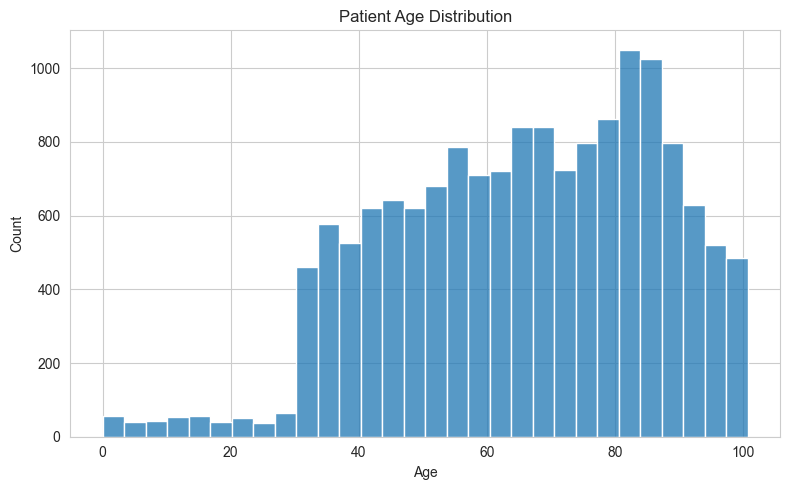

In [34]:
reference_date = patients["DEATHDATE"].fillna(REFERENCE_DATE)

patients["AGE"] = (
    reference_date - patients["BIRTHDATE"]
).dt.days / 365.25

plt.figure(figsize=(8,5))

sns.histplot(
    patients["AGE"],
    bins=30
)

plt.title("Patient Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")

plt.tight_layout()

plt.savefig(FIG_DIR / "overall_age_distribution.png")

plt.show()


## Gender
### Gender distribution for all patients 

In [35]:
# Gender summary table
patients_gender_summary = (
    patients["GENDER"]
    .value_counts()
    .reset_index()
)

patients_gender_summary.columns = [
    "GENDER",
    "PATIENT_COUNT"
]

patients_gender_summary


,GENDER,PATIENT_COUNT
0,M,8231
1,F,7123


## Race
### Race distribution for all patients

In [36]:
# Race summary table

patients_race_summary = (
    patients["RACE"]
    .value_counts()
    .reset_index()
)

patients_race_summary.columns = [
    "RACE",
    "PATIENT_COUNT"
]

patients_race_summary

,RACE,PATIENT_COUNT
0,white,12589
1,black,1277
2,asian,1104
3,hawaiian,167
4,other,162
5,native,55


## Ethnicity
### Ethnicity distribution for all patients

In [37]:
# Ethnicity summary table

patients_ethnicity_summary = (
    patients["ETHNICITY"]
    .value_counts()
    .reset_index()
)

patients_ethnicity_summary.columns = [
    "ETHNICITY",
    "PATIENT_COUNT"
]

patients_ethnicity_summary

,ETHNICITY,PATIENT_COUNT
0,nonhispanic,13743
1,hispanic,1611


# 6. Cancer Cohort Definition

Patients with cancer were identified using diagnosis terminology from the CONDITIONS table.
The selected terms were chosen to capture a broad range of common oncology-related terminology used in diagnosis descriptions.

For example:
- `cancer` and `malignant` capture general malignancy terminology
- `carcinoma` and `neoplasm` capture common solid tumor descriptions
- `leukemia` and `lymphoma` capture hematologic malignancies
- `melanoma` captures common skin malignancies

Using multiple related terms improves sensitivity and reduces the likelihood of missing cancer-related diagnoses that may not explicitly contain the word “cancer.”

This represents an initial rule-based phenotype definition using malignant neoplasm-related terminology.


In [38]:
cancer_terms = [
    "cancer",
    "malignant",
    "carcinoma",
    "neoplasm",
    "leukemia",
    "lymphoma",
    "melanoma"
]

pattern = "|".join(cancer_terms)

cancer_conditions = conditions[
    conditions["DESCRIPTION"]
    .str.contains(
        pattern,
        case=False,
        na=False
    )
].copy()

print("Cancer-related condition rows:", len(cancer_conditions))
print("Unique cancer patients:", cancer_conditions["PATIENT"].nunique())


Cancer-related condition rows: 5343
Unique cancer patients: 2533


In [39]:
cancer_conditions["DESCRIPTION"].value_counts().head(20)

DESCRIPTION
Neoplasm of prostate                                                     1268
Carcinoma in situ of prostate (disorder)                                 1159
Suspected lung cancer (situation)                                         540
Malignant neoplasm of breast (disorder)                                   512
Non-small cell lung cancer (disorder)                                     450
Non-small cell carcinoma of lung  TNM stage 1 (disorder)                  450
Overlapping malignant neoplasm of colon                                   260
Malignant tumor of colon                                                  200
Metastasis from malignant tumor of prostate (disorder)                    191
Small cell carcinoma of lung (disorder)                                    89
Primary small cell malignant neoplasm of lung  TNM stage 1 (disorder)      89
Primary malignant neoplasm of colon                                        83
Secondary malignant neoplasm of colon               

# 7. Build Patient-Level Cancer Cohort

In [40]:
first_cancer_dx = (
    cancer_conditions
    .groupby("PATIENT")["START"]
    .min()
    .reset_index()
    .rename(columns={"START":"FIRST_CANCER_DATE"})
)

cohort = first_cancer_dx.merge(
    patients,
    left_on="PATIENT",
    right_on="Id",
    how="left"
)

cohort.head()


,PATIENT,FIRST_CANCER_DATE,Id,BIRTHDATE,DEATHDATE,SSN,DRIVERS,PASSPORT,PREFIX,FIRST,LAST,SUFFIX,MAIDEN,MARITAL,RACE,ETHNICITY,GENDER,BIRTHPLACE,ADDRESS,CITY,STATE,COUNTY,ZIP,LAT,LON,HEALTHCARE_EXPENSES,HEALTHCARE_COVERAGE,AGE
0,000eba84-0d5c-2657-0b5e-0c70f2f746c2,1989-06-03,000eba84-0d5c-2657-0b5e-0c70f2f746c2,1929-04-06,NaT,999-18-7950,S99957211,X41011359X,Mr.,Boyce638,Johns824,NaN,NaN,M,white,nonhispanic,M,West Springfield Massachusetts US,902 Dibbert Common Apt 67,Dighton,Massachusetts,Bristol County,NaN,41.798910,-71.196704,3.008311e+06,297474.4500,93.601643
1,001209d3-9cd3-a700-69ea-c9982213efea,1989-02-04,001209d3-9cd3-a700-69ea-c9982213efea,1926-11-27,1992-10-22,999-74-9899,S99912221,X44113995X,Mr.,Michale231,Macejkovic424,NaN,NaN,M,black,nonhispanic,M,Sharon Massachusetts US,295 Wintheiser Throughway Suite 65,Swampscott,Massachusetts,Essex County,NaN,42.463916,-70.879934,1.670533e+06,191566.0775,65.902806
2,00553b46-47fb-e90c-ce55-c26b8ddc6de9,2009-04-01,00553b46-47fb-e90c-ce55-c26b8ddc6de9,1932-08-23,NaT,999-99-2906,S99952781,X61422441X,Mr.,Graham902,Senger904,NaN,NaN,M,white,nonhispanic,M,Quincy Massachusetts US,193 Bosco Rapid Suite 19,Fitchburg,Massachusetts,Worcester County,NaN,42.582840,-71.860661,1.314520e+07,151838.7775,90.220397
3,005ca8f0-e643-f614-fd0a-3872463aaacc,2014-01-24,005ca8f0-e643-f614-fd0a-3872463aaacc,1945-09-18,NaT,999-37-2166,S99998188,X20204168X,Mrs.,Juliette736,Jacobson885,MD,Ledner144,M,white,nonhispanic,F,Cambridge Massachusetts US,207 Lesch Crossing,Boston,Massachusetts,Suffolk County,2134.0,42.295264,-71.102500,1.322756e+06,137638.8785,77.149897
4,00626e2c-3fbf-3ee4-1f32-ea31daa4e72f,2011-11-16,00626e2c-3fbf-3ee4-1f32-ea31daa4e72f,1930-10-12,2014-02-22,999-28-9417,S99926467,X3694689X,Ms.,Milda157,Haley279,NaN,NaN,S,white,nonhispanic,F,East Harwich Massachusetts US,700 Donnelly Trace,Brookline,Massachusetts,Norfolk County,2446.0,42.279035,-71.159588,2.950068e+06,350315.1595,83.364819


In [41]:
cohort["AGE_AT_DIAGNOSIS"] = (
    cohort["FIRST_CANCER_DATE"] -
    cohort["BIRTHDATE"]
).dt.days / 365.25

cohort["AGE_AT_DIAGNOSIS"].describe()


count    2533.000000
mean       63.347307
std        11.064181
min         2.088980
25%        60.158795
50%        63.898700
75%        69.426420
max        97.952088
Name: AGE_AT_DIAGNOSIS, dtype: float64

In [42]:
# cohort_missingness = pd.DataFrame({

#     "Missing Count": [

#         cohort["AGE_AT_DIAGNOSIS"].isnull().sum(),

#         cohort["ENCOUNTER_COUNT"].isnull().sum(),

#         cohort["VALIDATED_COHORT"].isnull().sum(),

#         cohort["PHENOTYPE_CONFIDENCE"].isnull().sum(),

#     ],

#     "Missing Percent": [

#         round(
#             cohort["AGE_AT_DIAGNOSIS"].isnull().mean() * 100,
#             2
#         ),

#         round(
#             cohort["ENCOUNTER_COUNT"].isnull().mean() * 100,
#             2
#         ),

#         round(
#             cohort["VALIDATED_COHORT"].isnull().mean() * 100,
#             2
#         ),

#         round(
#             cohort["PHENOTYPE_CONFIDENCE"].isnull().mean() * 100,
#             2
#         )
#     ]

# },

# index=[

#     "cohort.AGE_AT_DIAGNOSIS",
#     "cohort.ENCOUNTER_COUNT",
#     "cohort.VALIDATED_COHORT",
#     "cohort.PHENOTYPE_CONFIDENCE"
# ])

# cohort_missingness

# 8. Cancer Cohort Demographics

### Age distribution 

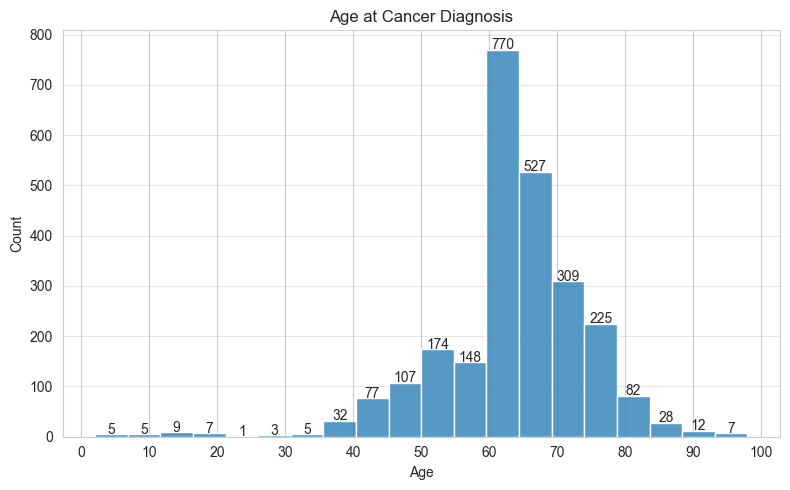

In [43]:
plt.figure(figsize=(8,5))

ax = sns.histplot(
    cohort["AGE_AT_DIAGNOSIS"],
    bins=20
)

# Add count labels
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        plt.text(
            p.get_x() + p.get_width()/2,
            height + 1,
            int(height),
            ha='center'
        )

# X-axis ticks every 10 years
plt.xticks(range(0, int(cohort["AGE_AT_DIAGNOSIS"].max()) + 10, 10))

plt.grid(axis='y', color='gray', alpha=0.2)

plt.title("Age at Cancer Diagnosis")
plt.xlabel("Age")
plt.ylabel("Count")

plt.tight_layout()

plt.savefig(FIG_DIR / "age_at_diagnosis.png")

plt.show()


### Cohort gender distribution

In [44]:
# Gender summary table
cohort_gender_summary = (
    cohort["GENDER"]
    .value_counts()
    .reset_index()
)

cohort_gender_summary.columns = [
    "GENDER",
    "PATIENT_COUNT"
]

cohort_gender_summary

,GENDER,PATIENT_COUNT
0,M,1773
1,F,760


### Cohort race distribution

In [45]:
cohort_race_summary = (
    cohort["RACE"]
    .value_counts()
    .reset_index()
)

cohort_race_summary.columns = [
    "RACE",
    "PATIENT_COUNT"
]

cohort_race_summary



,RACE,PATIENT_COUNT
0,white,2119
1,black,189
2,asian,183
3,hawaiian,22
4,other,12
5,native,8


### Cohort enthnicity distribution

In [46]:
cohort_ethnicity_summary = (
    cohort["ETHNICITY"]
    .value_counts()
    .reset_index()
)

cohort_ethnicity_summary.columns = [
    "ETHNICITY",
    "PATIENT_COUNT"
]

cohort_ethnicity_summary

,ETHNICITY,PATIENT_COUNT
0,nonhispanic,2263
1,hispanic,270


### Smoking status
Smoking status was explored as an additional cohort characterization variable due to its clinical relevance in oncology and population health studies.

Observation-level data was otherwise largely composed of general vitals and survey measurements rather than oncology-specific indicators.

In [47]:
# Smoking status characterization

smoking_obs = observations[
    observations["DESCRIPTION"] ==
    "Tobacco smoking status NHIS"
].copy()

smoking_status = (
    smoking_obs[
        ["PATIENT", "VALUE"]
    ]
    .drop_duplicates()
)

cohort_smoking = cohort.merge(
    smoking_status,
    left_on="PATIENT",
    right_on="PATIENT",
    how="left"
)

smoking_summary = (
    cohort_smoking["VALUE"]
    .value_counts()
    .reset_index()
)

smoking_summary.columns = [
    "SMOKING_STATUS",
    "PATIENT_COUNT"
]

smoking_summary

,SMOKING_STATUS,PATIENT_COUNT
0,Never smoker,1414
1,Former smoker,1116
2,Current every day smoker,2


# 9. Cancer Type Classification

In [48]:
def classify_cancer(description):

    description = str(description).lower()

    if "breast" in description:
        return "Breast"

    elif "lung" in description:
        return "Lung"

    elif "prostate" in description:
        return "Prostate"

    elif "colon" in description:
        return "Colon"

    elif "leukemia" in description:
        return "Leukemia"

    elif "skin" in description or "melanoma" in description:
        return "Skin"

    else:
        return "Other"


In [49]:
cancer_conditions["CANCER_TYPE"] = (
    cancer_conditions["DESCRIPTION"]
    .apply(classify_cancer)
)

cancer_type_counts = (
    cancer_conditions["CANCER_TYPE"]
    .value_counts()
)

cancer_type_counts


CANCER_TYPE
Prostate    2618
Lung        1618
Colon        595
Breast       512
Name: count, dtype: int64

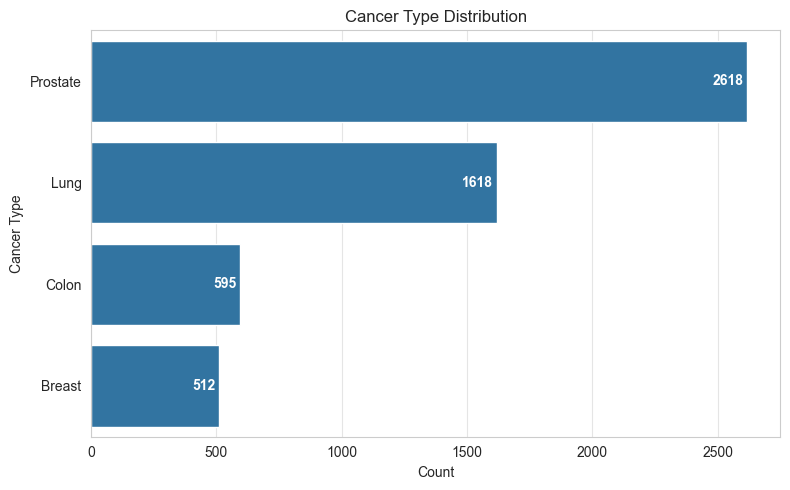

In [50]:
plt.figure(figsize=(8,5))

ax = sns.barplot(
    x=cancer_type_counts.values,
    y=cancer_type_counts.index
)

for p in ax.patches:
    width = p.get_width()
    plt.text(
        width - 15,
        p.get_y() + p.get_height()/2,
        int(width),
        ha='right',
        va='center',
        color='white',
        fontweight='bold'
    )

plt.grid(axis='x', color='gray', alpha=0.2)

plt.title("Cancer Type Distribution")
plt.xlabel("Count")
plt.ylabel("Cancer Type")

plt.tight_layout()

plt.savefig(FIG_DIR / "cancer_type_distribution.png")

plt.show()


# 10. Longitudinal Follow-Up and Healthcare Utilization

In [51]:
encounter_counts = (
    encounters.groupby("PATIENT")
    .size()
    .reset_index(name="ENCOUNTER_COUNT")
)

cohort = cohort.merge(
    encounter_counts,
    on="PATIENT",
    how="left"
)

cohort["ENCOUNTER_COUNT"].describe()


count    2533.000000
mean      155.130280
std       228.158198
min        13.000000
25%        65.000000
50%        93.000000
75%       134.000000
max      2065.000000
Name: ENCOUNTER_COUNT, dtype: float64

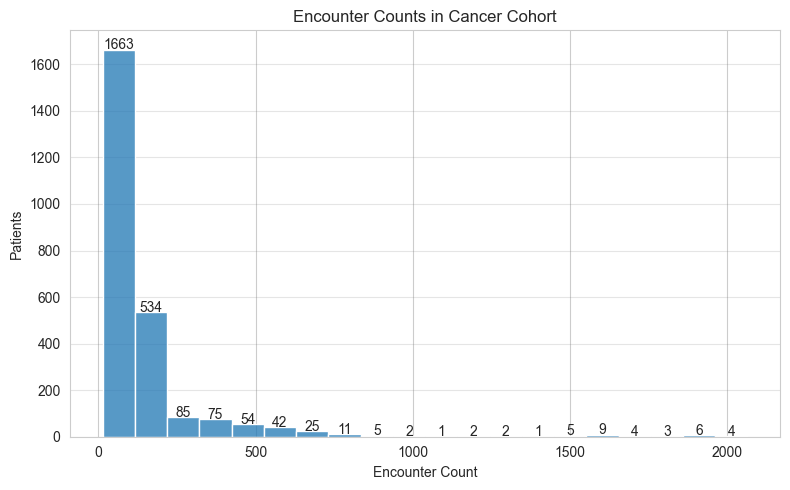

In [52]:
plt.figure(figsize=(8,5))

ax = sns.histplot(
    cohort["ENCOUNTER_COUNT"],
    bins=20
)

# Add count labels
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        plt.text(
            p.get_x() + p.get_width()/2,
            height + 1,
            int(height),
            ha='center'
        )

plt.grid(axis='y', color='gray', alpha=0.2)

plt.title("Encounter Counts in Cancer Cohort")
plt.xlabel("Encounter Count")
plt.ylabel("Patients")

plt.tight_layout()

plt.savefig(FIG_DIR / "encounter_distribution.png")

plt.show()


# 11. Medication-Based Validation

Medication records were explored as an additional validation layer for the diagnosis-based cancer cohort.


In [53]:
medications.head()

,START,STOP,PATIENT,PAYER,ENCOUNTER,CODE,DESCRIPTION,BASE_COST,PAYER_COVERAGE,DISPENSES,TOTALCOST,REASONCODE,REASONDESCRIPTION
0,1995-05-13 22:07:23+00:00,1996-05-18 22:07:23+00:00,5605b66b-e92d-c16c-1b83-b8bf7040d51f,6e2f1a2d-27bd-3701-8d08-dae202c58632,63023e17-bb98-6d93-5296-e1fceb93cbe9,310798,Hydrochlorothiazide 25 MG Oral Tablet,0.00,0.0,12,0.00,59621000.0,Hypertension
1,1995-05-13 22:07:23+00:00,1996-05-18 22:07:23+00:00,5605b66b-e92d-c16c-1b83-b8bf7040d51f,6e2f1a2d-27bd-3701-8d08-dae202c58632,63023e17-bb98-6d93-5296-e1fceb93cbe9,314076,lisinopril 10 MG Oral Tablet,0.01,0.0,371,3.71,59621000.0,Hypertension
2,1996-05-18 22:07:23+00:00,1997-05-24 22:07:23+00:00,5605b66b-e92d-c16c-1b83-b8bf7040d51f,047f6ec3-6215-35eb-9608-f9dda363a44c,9f1a2446-6109-ca43-b3cd-d5f22ba5b433,310798,Hydrochlorothiazide 25 MG Oral Tablet,0.00,0.0,12,0.00,59621000.0,Hypertension
3,1996-05-18 22:07:23+00:00,1997-05-24 22:07:23+00:00,5605b66b-e92d-c16c-1b83-b8bf7040d51f,047f6ec3-6215-35eb-9608-f9dda363a44c,9f1a2446-6109-ca43-b3cd-d5f22ba5b433,314076,lisinopril 10 MG Oral Tablet,0.01,0.0,371,3.71,59621000.0,Hypertension
4,1997-05-24 22:07:23+00:00,1998-05-30 22:07:23+00:00,5605b66b-e92d-c16c-1b83-b8bf7040d51f,42c4fca7-f8a9-3cd1-982a-dd9751bf3e2a,c51977a5-225e-a87b-08ec-3280e7c9acca,310798,Hydrochlorothiazide 25 MG Oral Tablet,0.00,0.0,12,0.00,59621000.0,Hypertension


In [54]:
medications["REASONDESCRIPTION"] \
    .value_counts() \
    .head(20)


REASONDESCRIPTION
Hypertension                                                             613347
Diabetes                                                                 250539
Anemia (disorder)                                                         82414
Hyperlipidemia                                                            76217
Childhood asthma                                                          66680
Non-small cell carcinoma of lung  TNM stage 1 (disorder)                  38842
Pulmonary emphysema (disorder)                                            24424
Chronic obstructive bronchitis (disorder)                                 18236
Chronic congestive heart failure (disorder)                               17802
Primary small cell malignant neoplasm of lung  TNM stage 1 (disorder)      9458
Acute bronchitis (disorder)                                                7749
Viral sinusitis (disorder)                                                 3382
Alzheimer's disease (d

In [55]:
medication_validation_terms = [
    "cancer",
    "carcinoma",
    "malignant",
    "neoplasm",
    "leukemia",
    "lymphoma",
    "melanoma"
]

med_pattern = "|".join(medication_validation_terms)

oncology_related_meds = medications[
    medications["REASONDESCRIPTION"]
    .str.contains(
        med_pattern,
        case=False,
        na=False
    )
].copy()

print(
    "Patients with oncology-related medications:",
    oncology_related_meds["PATIENT"].nunique()
)

oncology_related_meds.head()


Patients with oncology-related medications: 1240


,START,STOP,PATIENT,PAYER,ENCOUNTER,CODE,DESCRIPTION,BASE_COST,PAYER_COVERAGE,DISPENSES,TOTALCOST,REASONCODE,REASONDESCRIPTION
303,2005-03-10 04:35:50+00:00,2005-03-10 04:35:50+00:00,94d39619-8e17-d248-41b3-9ec1f2d031b2,6e2f1a2d-27bd-3701-8d08-dae202c58632,2dba409c-6d9b-90d3-c2ed-aeb6e44c3e8e,1736854,Cisplatin 50 MG Injection,213.75,104.06,1,213.75,424132000.0,Non-small cell carcinoma of lung TNM stage 1 ...
304,2005-03-10 04:35:50+00:00,2005-03-10 04:35:50+00:00,94d39619-8e17-d248-41b3-9ec1f2d031b2,6e2f1a2d-27bd-3701-8d08-dae202c58632,2dba409c-6d9b-90d3-c2ed-aeb6e44c3e8e,583214,PACLitaxel 100 MG Injection,3224.08,2361.81,1,3224.08,424132000.0,Non-small cell carcinoma of lung TNM stage 1 ...
305,2005-04-10 02:57:50+00:00,2005-04-10 02:57:50+00:00,94d39619-8e17-d248-41b3-9ec1f2d031b2,6e2f1a2d-27bd-3701-8d08-dae202c58632,a468a706-9964-3a46-f1c4-d525d4c164be,1736854,Cisplatin 50 MG Injection,218.85,107.89,1,218.85,424132000.0,Non-small cell carcinoma of lung TNM stage 1 ...
306,2005-04-10 02:57:50+00:00,2005-04-10 02:57:50+00:00,94d39619-8e17-d248-41b3-9ec1f2d031b2,6e2f1a2d-27bd-3701-8d08-dae202c58632,a468a706-9964-3a46-f1c4-d525d4c164be,583214,PACLitaxel 100 MG Injection,3270.03,2396.27,1,3270.03,424132000.0,Non-small cell carcinoma of lung TNM stage 1 ...
309,2005-05-10 14:29:50+00:00,2005-05-10 14:29:50+00:00,94d39619-8e17-d248-41b3-9ec1f2d031b2,6e2f1a2d-27bd-3701-8d08-dae202c58632,c0499837-50da-8002-e245-f55f443fcc9e,1736854,Cisplatin 50 MG Injection,218.66,107.75,1,218.66,424132000.0,Non-small cell carcinoma of lung TNM stage 1 ...


# 12. Procedure-Based Validation

In [56]:
procedures.head()

,START,STOP,PATIENT,ENCOUNTER,CODE,DESCRIPTION,BASE_COST,REASONCODE,REASONDESCRIPTION
0,2012-11-21 08:36:35+00:00,2012-11-21 09:09:12+00:00,c06a2ab3-c3b1-a3d0-7c12-262a12c6885e,cb739cd1-4540-e729-2ef1-fc09075f521c,73761001,Colonoscopy,6133.93,NaN,NaN
1,2012-08-18 22:07:23+00:00,2012-08-18 22:45:32+00:00,5605b66b-e92d-c16c-1b83-b8bf7040d51f,e5e22010-0649-229f-013a-44b804bffb11,710824005,Assessment of health and social care needs (pr...,431.40,NaN,NaN
2,2012-08-18 22:07:23+00:00,2012-08-18 22:22:23+00:00,5605b66b-e92d-c16c-1b83-b8bf7040d51f,e5e22010-0649-229f-013a-44b804bffb11,430193006,Medication Reconciliation (procedure),436.43,NaN,NaN
3,2012-08-18 22:45:32+00:00,2012-08-18 23:26:17+00:00,5605b66b-e92d-c16c-1b83-b8bf7040d51f,e5e22010-0649-229f-013a-44b804bffb11,866148006,Screening for domestic abuse (procedure),431.40,NaN,NaN
4,2012-08-18 23:26:17+00:00,2012-08-18 23:38:08+00:00,5605b66b-e92d-c16c-1b83-b8bf7040d51f,e5e22010-0649-229f-013a-44b804bffb11,171207006,Depression screening (procedure),431.40,NaN,NaN


In [57]:
procedures["DESCRIPTION"] \
    .value_counts() \
    .head(20)


DESCRIPTION
Hospice care (regime/therapy)                                                           320218
Assessment of health and social care needs (procedure)                                  196569
Depression screening (procedure)                                                        154659
Depression screening using Patient Health Questionnaire Two-Item score (procedure)      153951
Nursing care/supplementary surveillance (regime/therapy)                                122349
Assessment of substance use (procedure)                                                 120315
Physical therapy procedure (regime/therapy)                                             113472
Occupational therapy (regime/therapy)                                                   109734
Medication Reconciliation (procedure)                                                    99283
Assessment of anxiety (procedure)                                                        95554
Renal dialysis (procedure)            

In [58]:
procedure_validation_terms = [
    "biopsy",
    "colonoscopy",
    "mastectomy",
    "resection",
    "radiation",
    "oncology"
]

proc_pattern = "|".join(procedure_validation_terms)

oncology_related_procedures = procedures[
    procedures["DESCRIPTION"]
    .str.contains(
        proc_pattern,
        case=False,
        na=False
    )
].copy()

print(
    "Patients with oncology-related procedures:",
    oncology_related_procedures["PATIENT"].nunique()
)

oncology_related_procedures.head()


Patients with oncology-related procedures: 6488


,START,STOP,PATIENT,ENCOUNTER,CODE,DESCRIPTION,BASE_COST,REASONCODE,REASONDESCRIPTION
0,2012-11-21 08:36:35+00:00,2012-11-21 09:09:12+00:00,c06a2ab3-c3b1-a3d0-7c12-262a12c6885e,cb739cd1-4540-e729-2ef1-fc09075f521c,73761001,Colonoscopy,6133.93,NaN,NaN
245,2016-05-30 19:41:42+00:00,2016-05-30 20:20:31+00:00,6e5ae27c-8038-7988-e2c0-25a103f01bfa,3addefcb-083f-a1e6-df4f-a244d3de93e7,73761001,Colonoscopy,16330.87,NaN,NaN
256,2017-08-04 20:20:31+00:00,2017-08-04 20:47:04+00:00,6e5ae27c-8038-7988-e2c0-25a103f01bfa,25cb17dc-b3c3-56ae-5296-e339f087e048,73761001,Colonoscopy,11311.46,NaN,NaN
698,2005-03-10 04:35:50+00:00,2005-03-10 07:27:50+00:00,94d39619-8e17-d248-41b3-9ec1f2d031b2,2dba409c-6d9b-90d3-c2ed-aeb6e44c3e8e,703423002,Combined chemotherapy and radiation therapy (p...,14580.28,424132000.0,Non-small cell carcinoma of lung TNM stage 1 ...
701,2005-04-10 02:57:50+00:00,2005-04-10 05:59:50+00:00,94d39619-8e17-d248-41b3-9ec1f2d031b2,a468a706-9964-3a46-f1c4-d525d4c164be,703423002,Combined chemotherapy and radiation therapy (p...,8467.74,424132000.0,Non-small cell carcinoma of lung TNM stage 1 ...


# 13. Multi-Evidence Phenotype Validation

In [59]:
med_validated = set(
    oncology_related_meds["PATIENT"]
)

proc_validated = set(
    oncology_related_procedures["PATIENT"]
)

cohort["MEDICATION_VALIDATED"] = (
    cohort["PATIENT"]
    .isin(med_validated)
)

cohort["PROCEDURE_VALIDATED"] = (
    cohort["PATIENT"]
    .isin(proc_validated)
)

cohort.head()


,PATIENT,FIRST_CANCER_DATE,Id,BIRTHDATE,DEATHDATE,SSN,DRIVERS,PASSPORT,PREFIX,FIRST,LAST,SUFFIX,MAIDEN,MARITAL,RACE,ETHNICITY,GENDER,BIRTHPLACE,ADDRESS,CITY,STATE,COUNTY,ZIP,LAT,LON,HEALTHCARE_EXPENSES,HEALTHCARE_COVERAGE,AGE,AGE_AT_DIAGNOSIS,ENCOUNTER_COUNT,MEDICATION_VALIDATED,PROCEDURE_VALIDATED
0,000eba84-0d5c-2657-0b5e-0c70f2f746c2,1989-06-03,000eba84-0d5c-2657-0b5e-0c70f2f746c2,1929-04-06,NaT,999-18-7950,S99957211,X41011359X,Mr.,Boyce638,Johns824,NaN,NaN,M,white,nonhispanic,M,West Springfield Massachusetts US,902 Dibbert Common Apt 67,Dighton,Massachusetts,Bristol County,NaN,41.798910,-71.196704,3.008311e+06,297474.4500,93.601643,60.158795,140,False,False
1,001209d3-9cd3-a700-69ea-c9982213efea,1989-02-04,001209d3-9cd3-a700-69ea-c9982213efea,1926-11-27,1992-10-22,999-74-9899,S99912221,X44113995X,Mr.,Michale231,Macejkovic424,NaN,NaN,M,black,nonhispanic,M,Sharon Massachusetts US,295 Wintheiser Throughway Suite 65,Swampscott,Massachusetts,Essex County,NaN,42.463916,-70.879934,1.670533e+06,191566.0775,65.902806,62.190281,48,True,True
2,00553b46-47fb-e90c-ce55-c26b8ddc6de9,2009-04-01,00553b46-47fb-e90c-ce55-c26b8ddc6de9,1932-08-23,NaT,999-99-2906,S99952781,X61422441X,Mr.,Graham902,Senger904,NaN,NaN,M,white,nonhispanic,M,Quincy Massachusetts US,193 Bosco Rapid Suite 19,Fitchburg,Massachusetts,Worcester County,NaN,42.582840,-71.860661,1.314520e+07,151838.7775,90.220397,76.605065,435,False,False
3,005ca8f0-e643-f614-fd0a-3872463aaacc,2014-01-24,005ca8f0-e643-f614-fd0a-3872463aaacc,1945-09-18,NaT,999-37-2166,S99998188,X20204168X,Mrs.,Juliette736,Jacobson885,MD,Ledner144,M,white,nonhispanic,F,Cambridge Massachusetts US,207 Lesch Crossing,Boston,Massachusetts,Suffolk County,2134.0,42.295264,-71.102500,1.322756e+06,137638.8785,77.149897,68.350445,86,True,True
4,00626e2c-3fbf-3ee4-1f32-ea31daa4e72f,2011-11-16,00626e2c-3fbf-3ee4-1f32-ea31daa4e72f,1930-10-12,2014-02-22,999-28-9417,S99926467,X3694689X,Ms.,Milda157,Haley279,NaN,NaN,S,white,nonhispanic,F,East Harwich Massachusetts US,700 Donnelly Trace,Brookline,Massachusetts,Norfolk County,2446.0,42.279035,-71.159588,2.950068e+06,350315.1595,83.364819,81.095140,181,True,True


In [60]:
cohort.groupby(
    "MEDICATION_VALIDATED"
)["ENCOUNTER_COUNT"] \
.describe()


,count,mean,std,min,25%,50%,75%,max
MEDICATION_VALIDATED,,,,,,,,
False,1470.0,166.024490,260.728188,13.0,62.0,88.0,130.0,2065.0
True,1063.0,140.064911,172.303133,22.0,70.0,99.0,137.0,1901.0


# 14. Validated Cohort Refinement

The validated cohort represents patients with diagnosis-based cancer evidence together with at least one additional supporting evidence source, such as oncology-related medications or cancer-associated procedures.


In [61]:
cohort["VALIDATED_COHORT"] = (
    cohort["MEDICATION_VALIDATED"]
    |
    cohort["PROCEDURE_VALIDATED"]
)


In [62]:
initial_count = len(cohort)

validated_count = (
    cohort["VALIDATED_COHORT"]
    .sum()
)

excluded_count = (
    initial_count - validated_count
)

print(f"Initial cohort: {initial_count}")
print(f"Validated cohort: {validated_count}")
print(f"Excluded after validation: {excluded_count}")


Initial cohort: 2533
Validated cohort: 1939
Excluded after validation: 594


In [63]:
validation_flow = pd.DataFrame({

    "Cohort Stage": [
        "Initial Diagnosis Cohort",
        "Validated Cohort",
        "Excluded After Validation"
    ],

    "Patient Count": [
        initial_count,
        validated_count,
        excluded_count
    ]
})

validation_flow


,Cohort Stage,Patient Count
0,Initial Diagnosis Cohort,2533
1,Validated Cohort,1939
2,Excluded After Validation,594


In [64]:
cohort.groupby(
    "VALIDATED_COHORT"
)["ENCOUNTER_COUNT"] \
.describe()


,count,mean,std,min,25%,50%,75%,max
VALIDATED_COHORT,,,,,,,,
False,594.0,223.821549,321.679853,30.0,79.0,109.0,170.75,2065.0
True,1939.0,134.087158,185.632542,13.0,61.0,87.0,129.00,1988.0


# 14A. Post-Validation Cohort Comparison

The validated cohort was compared against the initial diagnosis-based cohort to evaluate whether refinement steps altered demographic or healthcare utilization patterns.

These comparisons help assess phenotype plausibility and demonstrate the impact of cohort refinement strategies.


## Age at Diagnosis Comparison

Comparing age distributions before and after validation may help identify whether validated patients demonstrate distinct demographic patterns.


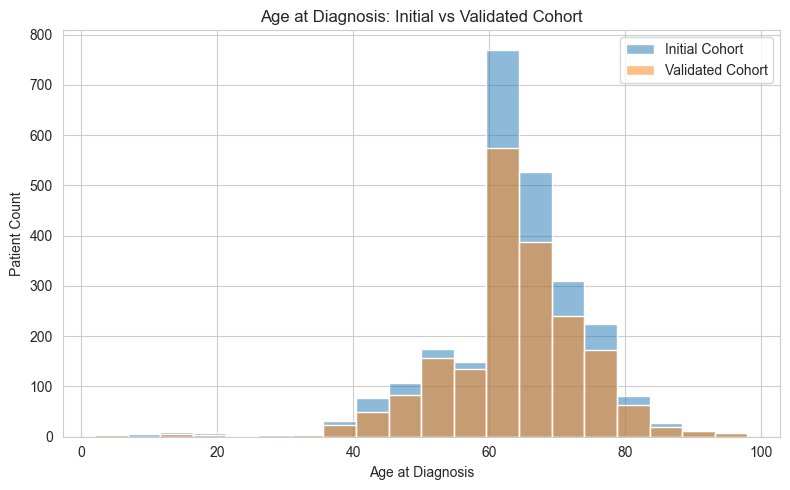

In [65]:
# Create validated subset

validated_subset = cohort[
    cohort["VALIDATED_COHORT"]
].copy()

plt.figure(figsize=(8,5))

sns.histplot(
    cohort["AGE_AT_DIAGNOSIS"],
    bins=20,
    alpha=0.5,
    label="Initial Cohort"
)

sns.histplot(
    validated_subset["AGE_AT_DIAGNOSIS"],
    bins=20,
    alpha=0.5,
    label="Validated Cohort"
)

plt.title(
    "Age at Diagnosis: Initial vs Validated Cohort"
)

plt.xlabel("Age at Diagnosis")
plt.ylabel("Patient Count")

plt.legend()

plt.tight_layout()

plt.savefig(
    FIG_DIR / "validated_age_comparison.png"
)

plt.show()


## Healthcare Utilization Comparison

Validated patients may demonstrate higher healthcare utilization due to increased longitudinal evidence, specialty care, or treatment-related encounters.


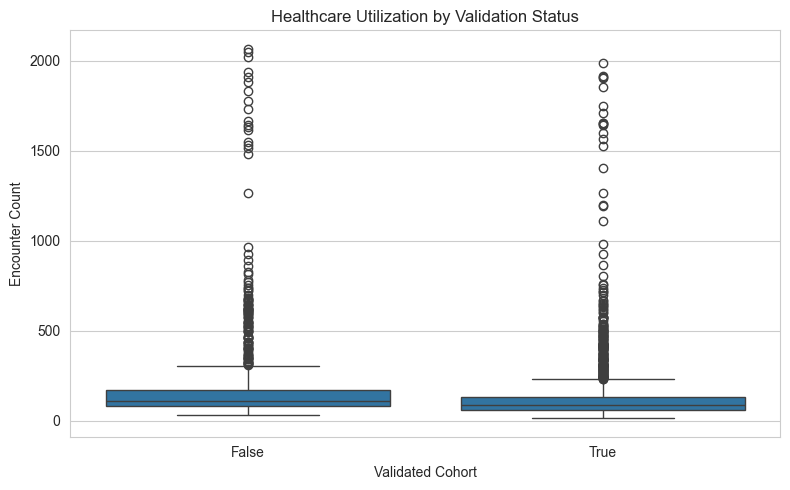

In [66]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=cohort,
    x="VALIDATED_COHORT",
    y="ENCOUNTER_COUNT"
)

plt.title(
    "Healthcare Utilization by Validation Status"
)

plt.xlabel("Validated Cohort")
plt.ylabel("Encounter Count")

plt.tight_layout()

plt.savefig(
    FIG_DIR / "utilization_by_validation.png"
)

plt.show()


# Interpretation

Patients retained after validation demonstrated longitudinal utilization patterns and supporting evidence sources consistent with higher-confidence cancer phenotypes.

These comparisons illustrate how iterative cohort refinement may improve phenotype specificity and strengthen downstream healthcare analytics workflows.


# 15. Phenotype Confidence Scoring

A simplified evidence-based phenotype confidence framework was developed to demonstrate how multiple validation sources may be combined in healthcare analytics workflows.


In [67]:
cohort["VALIDATION_SCORE"] = (
    1
    + cohort["MEDICATION_VALIDATED"].astype(int)
    + cohort["PROCEDURE_VALIDATED"].astype(int)
)

cohort["VALIDATION_SCORE"].value_counts().sort_index()


VALIDATION_SCORE
1     594
2     913
3    1026
Name: count, dtype: int64

In [68]:
def classify_confidence(score):

    if score == 1:
        return "Low Confidence"

    elif score == 2:
        return "Moderate Confidence"

    else:
        return "High Confidence"

cohort["PHENOTYPE_CONFIDENCE"] = (
    cohort["VALIDATION_SCORE"]
    .apply(classify_confidence)
)

cohort["PHENOTYPE_CONFIDENCE"].value_counts()


PHENOTYPE_CONFIDENCE
High Confidence        1026
Moderate Confidence     913
Low Confidence          594
Name: count, dtype: int64

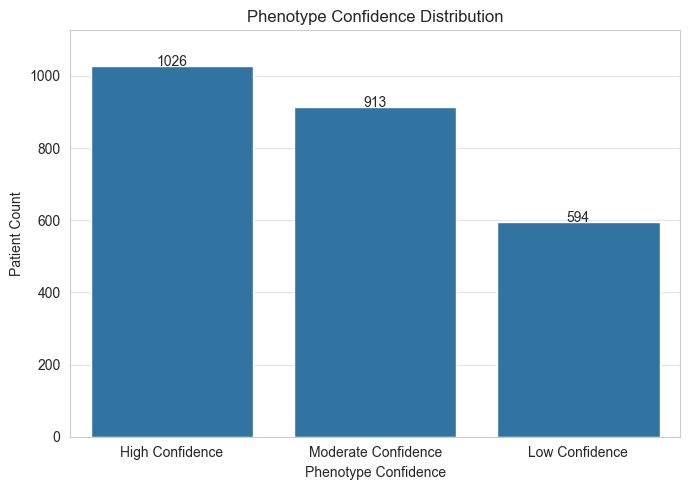

In [69]:
plt.figure(figsize=(7,5))

confidence_counts = (
    cohort["PHENOTYPE_CONFIDENCE"]
    .value_counts()
)

ax = sns.barplot(
    x=confidence_counts.index,
    y=confidence_counts.values
)

# Add count labels
for i, v in enumerate(confidence_counts.values):
    plt.text(i, v + 1, str(v), ha='center')

plt.grid(axis='y', color='gray', alpha=0.2)

plt.title("Phenotype Confidence Distribution")
plt.xlabel("Phenotype Confidence")
plt.ylabel("Patient Count")

plt.ylim(top=max(confidence_counts.values) + 100)

plt.tight_layout()

plt.savefig(
    FIG_DIR / "phenotype_confidence_distribution.png"
)

plt.show()


# 16. Final Cohort Export

The final exported cohort includes:
- diagnosis-based cohort membership
- validation evidence flags
- phenotype confidence scores
- longitudinal utilization metrics


In [70]:
# Enhanced cohort flow summary

cohort_flow = pd.DataFrame({

    "Cohort Stage": [
        "Total Dataset Population",
        "Initial Diagnosis-Based Cancer Cohort",
        "Medication-Validated Patients",
        "Procedure-Validated Patients",
        "Final Validated Cancer Cohort",
        "Excluded After Validation"
    ],

    "Patient Count": [

        total_patients,

        initial_count,

        cohort["MEDICATION_VALIDATED"].sum(),

        cohort["PROCEDURE_VALIDATED"].sum(),

        validated_count,

        excluded_count   ]
})

cohort_flow["Percent of Initial Cohort"] = (
    cohort_flow["Patient Count"] /
    initial_count * 100
).round(1)

cohort_flow


,Cohort Stage,Patient Count,Percent of Initial Cohort
0,Total Dataset Population,15354,606.2
1,Initial Diagnosis-Based Cancer Cohort,2533,100.0
2,Medication-Validated Patients,1063,42.0
3,Procedure-Validated Patients,1902,75.1
4,Final Validated Cancer Cohort,1939,76.5
5,Excluded After Validation,594,23.5


In [71]:
# Export cohort flow summary

cohort_flow.to_csv(

    PROCESSED_DIR / "cohort_flow_summary.csv",

    index=False

)
# Export full enriched cohort
cohort.to_csv(
    PROCESSED_DIR / "full_cancer_cohort.csv",
    index=False
)

# Export validated cohort
validated_cohort = cohort[
    cohort["VALIDATED_COHORT"]
].copy()

validated_cohort.to_csv(
    PROCESSED_DIR / "validated_cancer_cohort.csv",
    index=False
)

# Export excluded patients
excluded_cohort = cohort[
    ~cohort["VALIDATED_COHORT"]
].copy()

excluded_cohort.to_csv(
    PROCESSED_DIR / "excluded_after_validation.csv",
    index=False
)

# Export phenotype summary
phenotype_summary = (
    cohort["PHENOTYPE_CONFIDENCE"]
    .value_counts()
    .reset_index()
)

phenotype_summary.columns = [
    "PHENOTYPE_CONFIDENCE",
    "PATIENT_COUNT"
]

phenotype_summary.to_csv(
    PROCESSED_DIR / "phenotype_confidence_summary.csv",
    index=False
)

print("All cohort exports completed successfully.")


All cohort exports completed successfully.


# 17. Sources of Potential Misclassification

## Possible Sources of False Positives
- rule-out diagnoses
- historical cancer diagnoses
- benign neoplasms captured by broad keyword matching
- coding inconsistencies

## Possible Sources of False Negatives
- incomplete encounter history
- under-coded malignancies
- missing structured documentation

A broad diagnosis-based approach generally improves sensitivity but may reduce specificity. More restrictive phenotyping approaches may improve specificity while excluding valid cancer patients.


# 18. Real-World EMR Refinement Opportunities

Potential production-grade cohort refinement strategies may include:
- pathology confirmation
- tumor registry linkage
- ICD/SNOMED harmonization
- NLP on oncology notes
- temporal event modeling
- probabilistic phenotype scoring
- longitudinal treatment pathway analysis


# 19. Conclusion

This analysis demonstrated:
- longitudinal EHR exploration
- rule-based cohort engineering
- healthcare utilization analysis
- multi-evidence validation workflows
- phenotype confidence scoring
- clinically informed cohort reasoning

The workflow emphasizes reproducibility, transparency, and scalable healthcare analytics practices.
